In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("retail_sales.csv")

print(df.head())

  Order_ID  Order_Date Product_Category        Product  Quantity  Unit_Price  \
0  ORD0001  2025-04-25      Electronics     Headphones         3       10830   
1  ORD0002  2025-02-17           Sports  Tennis Racket         1         800   
2  ORD0003  2025-10-29           Sports  Tennis Racket         2        5090   
3  ORD0004  2025-06-22   Home & Kitchen           Lamp         2        2500   
4  ORD0005  2025-01-23   Home & Kitchen           Lamp         5        3000   

   Total_Sales Customer_Gender  Customer_Age Region Payment_Method  
0        32490            Male            65  North            UPI  
1          800            Male            32  North    Credit Card  
2        10180          Female            18  South           Cash  
3         5000            Male            23   West            UPI  
4        15000          Female            52  North           Cash  


In [3]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Shape: (500, 11)

Columns:
Index(['Order_ID', 'Order_Date', 'Product_Category', 'Product', 'Quantity',
       'Unit_Price', 'Total_Sales', 'Customer_Gender', 'Customer_Age',
       'Region', 'Payment_Method'],
      dtype='object')

Data Types:
Order_ID            object
Order_Date          object
Product_Category    object
Product             object
Quantity             int64
Unit_Price           int64
Total_Sales          int64
Customer_Gender     object
Customer_Age         int64
Region              object
Payment_Method      object
dtype: object


In [4]:
print(df.isnull().sum())

Order_ID            0
Order_Date          0
Product_Category    0
Product             0
Quantity            0
Unit_Price          0
Total_Sales         0
Customer_Gender     0
Customer_Age        0
Region              0
Payment_Method      0
dtype: int64


In [5]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [6]:
print(df.describe())

         Quantity    Unit_Price   Total_Sales  Customer_Age
count  500.000000    500.000000     500.00000    500.000000
mean     3.008000   5952.220000   17391.30000     41.230000
std      1.408511   6681.117056   22428.44359     13.677252
min      1.000000    210.000000     400.00000     18.000000
25%      2.000000   1787.500000    4235.00000     30.000000
50%      3.000000   3335.000000    9385.00000     41.000000
75%      4.000000   7135.000000   20837.50000     53.000000
max      5.000000  29870.000000  129700.00000     65.000000


In [7]:
total_sales = df["Total_Sales"].sum()

print("Total Sales: ₹", total_sales)

Total Sales: ₹ 8695650


In [8]:
total_quantity = df["Quantity"].sum()

print("Total Quantity Sold:", total_quantity)

Total Quantity Sold: 1504


In [9]:
average_order = df["Total_Sales"].mean()

print("Average Order Value: ₹", round(average_order, 2))

Average Order Value: ₹ 17391.3


In [10]:
category_sales = df.groupby("Product_Category")["Total_Sales"].sum()

print(category_sales)

Product_Category
Beauty             430400
Clothing           928830
Electronics       4747330
Home & Kitchen    1279720
Sports            1309370
Name: Total_Sales, dtype: int64


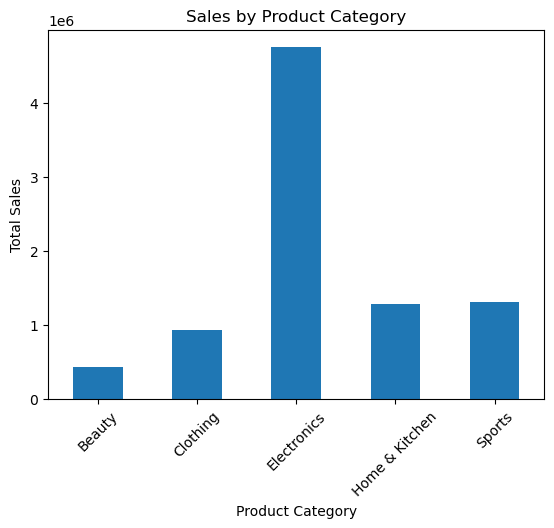

In [11]:
category_sales.plot(kind="bar")

plt.title("Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

In [12]:
product_sales = df.groupby("Product")["Total_Sales"].sum()

product_sales = product_sales.sort_values(ascending=False)

print(product_sales)

Product
Keyboard         1439560
Headphones        866570
Smartwatch        825290
Mouse             819560
Smartphone        796350
Cookware Set      377240
Bedsheet          361310
Yoga Mat          285030
Football          284970
T-Shirt           278990
Tennis Racket     256420
Cricket Bat       255370
Lamp              252960
Dumbbells         227580
Sneakers          195790
Storage Box       165610
Dress             160430
Jacket            147300
Jeans             146320
Mixer             122600
Moisturizer       121020
Shampoo            84950
Lipstick           77300
Face Wash          76220
Perfume            70910
Name: Total_Sales, dtype: int64


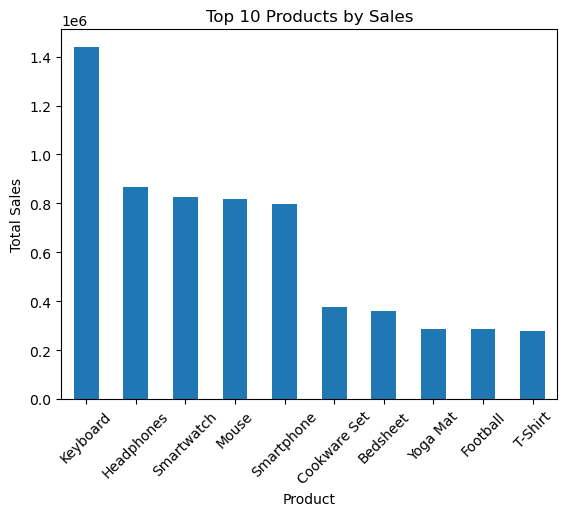

In [13]:
product_sales.head(10).plot(kind="bar")

plt.title("Top 10 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

In [14]:
region_sales = df.groupby("Region")["Total_Sales"].sum()

print(region_sales)

Region
East     2395430
North    2325120
South    2073890
West     1901210
Name: Total_Sales, dtype: int64


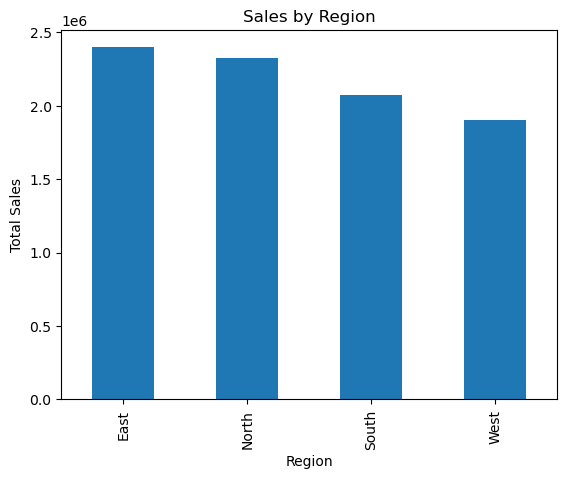

In [15]:
region_sales.plot(kind="bar")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()

In [16]:
gender_sales = df.groupby("Customer_Gender")["Total_Sales"].sum()

print(gender_sales)

Customer_Gender
Female    4568360
Male      4127290
Name: Total_Sales, dtype: int64


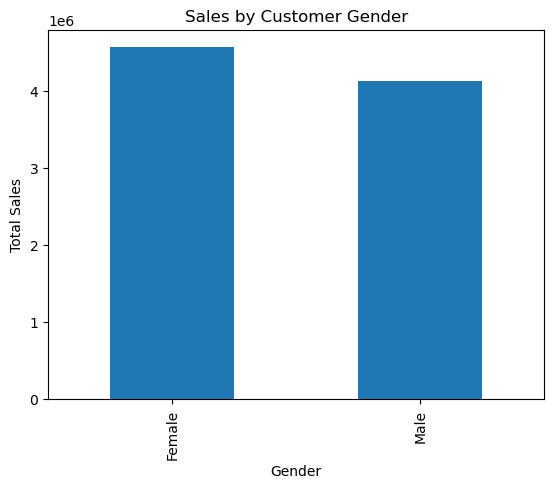

In [17]:
gender_sales.plot(kind="bar")

plt.title("Sales by Customer Gender")
plt.xlabel("Gender")
plt.ylabel("Total Sales")

plt.show()

In [18]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

In [19]:
df["Month"] = df["Order_Date"].dt.month

In [20]:
monthly_sales = df.groupby("Month")["Total_Sales"].sum()

print(monthly_sales)

Month
1      350650
2      958860
3      922450
4      331690
5      507000
6      915740
7      407170
8      956070
9      875070
10    1241880
11     734200
12     494870
Name: Total_Sales, dtype: int64


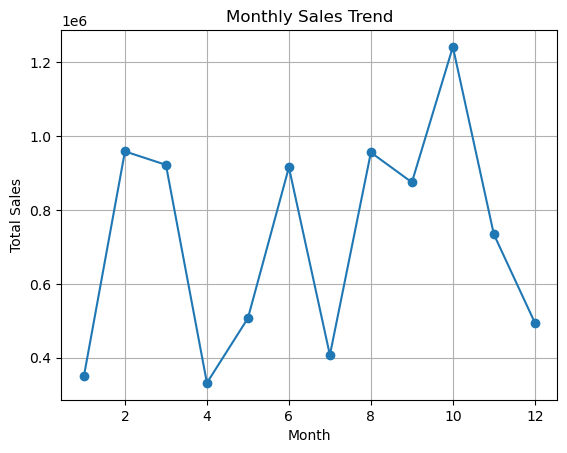

In [21]:
monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.grid()

plt.show()